# 1. Why Face Alignment Needed

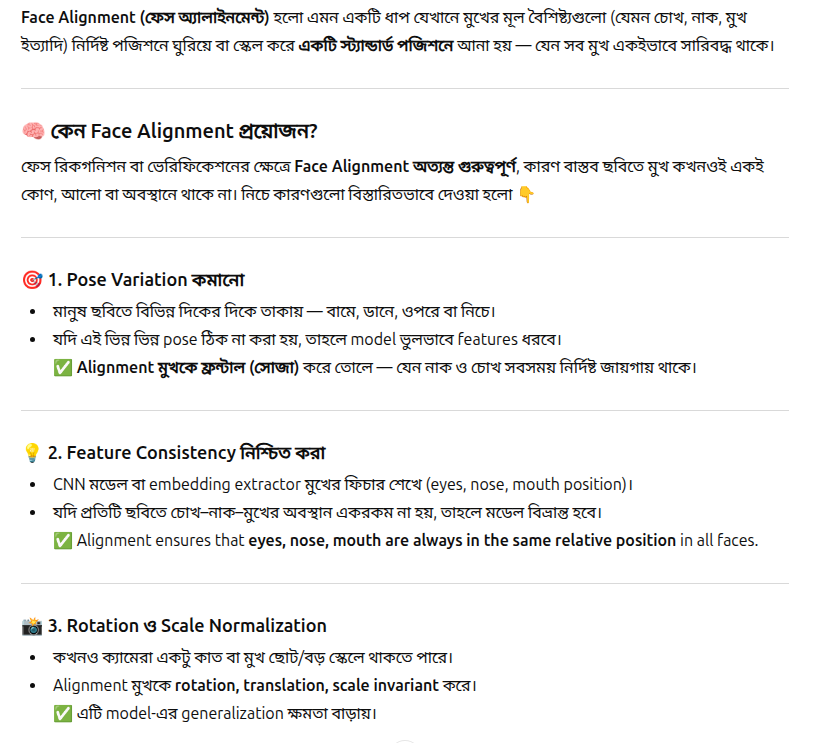

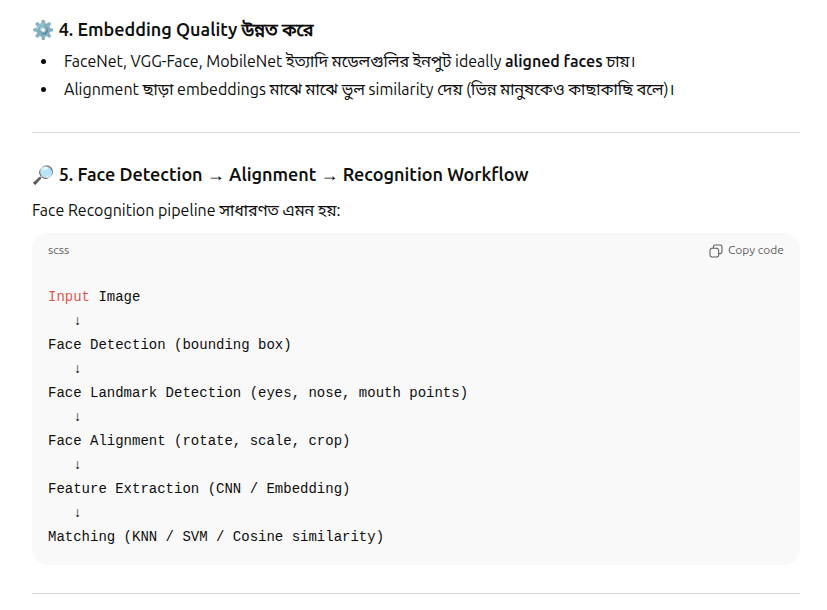

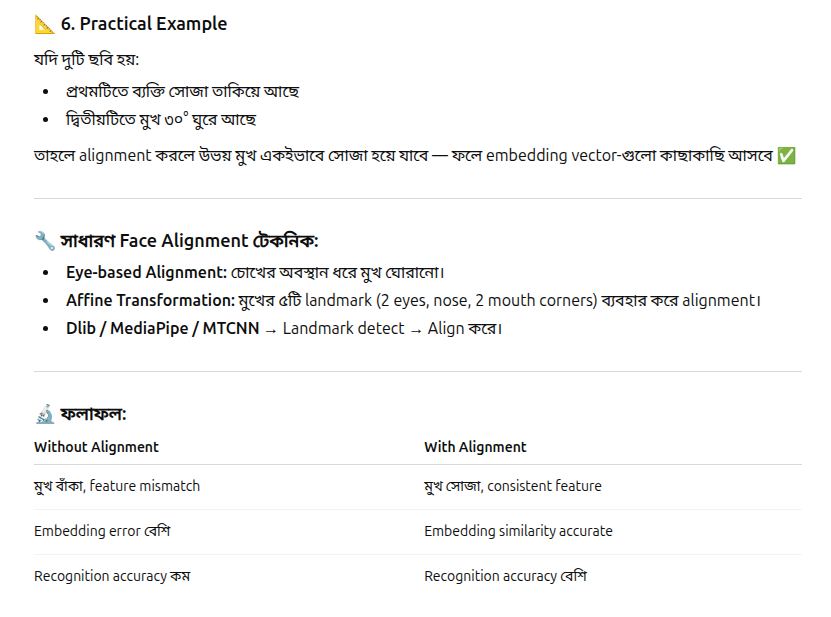

## 1. Face Alignment using MediaPipe ভিত্তিক (Lightweight, Fast)

I0000 00:00:1761534758.223672   12022 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761534758.227343   12794 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1761534758.232644   12788 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761534758.268700   12785 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


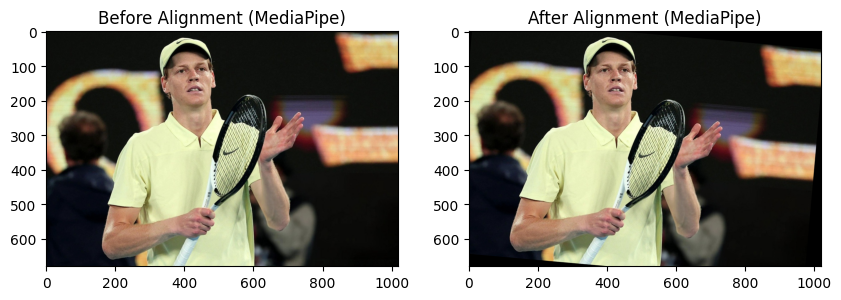

In [5]:
# --------------------------------------
# ✅ MediaPipe Face Alignment (Fixed Version)
# --------------------------------------

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# Ensure correct protobuf version (run once)
# !pip install protobuf==3.20.*

mp_face_mesh = mp.solutions.face_mesh

def mediapipe_align_face(image):
    h, w = image.shape[:2]
    
    # Initialize FaceMesh
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        refine_landmarks=True,
        max_num_faces=1,
        min_detection_confidence=0.5
    ) as face_mesh:
        
        # Convert image to RGB for MediaPipe
        results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            print("⚠️ No face detected!")
            return image
        
        # Get landmarks
        landmarks = results.multi_face_landmarks[0]
        left_eye = landmarks.landmark[33]   # Left eye outer corner
        right_eye = landmarks.landmark[263] # Right eye outer corner

        # Convert normalized coordinates to pixel coordinates
        left = np.array([left_eye.x * w, left_eye.y * h])
        right = np.array([right_eye.x * w, right_eye.y * h])

        # Calculate rotation angle
        dy, dx = right[1] - left[1], right[0] - left[0]
        angle = np.degrees(np.arctan2(dy, dx))
        
        # Center between eyes
        center = ((left[0] + right[0]) / 2, (left[1] + right[1]) / 2)

        # Get rotation matrix & warp image
        M = cv2.getRotationMatrix2D(center, angle, 1)
        aligned = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC)

    return aligned


# ------------------------------
# Load and visualize
# ------------------------------
img_path = "../dataset/test/sinner/sinner.jpeg"
image = cv2.imread(img_path)
aligned = mediapipe_align_face(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Before Alignment (MediaPipe)")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.title("After Alignment (MediaPipe)")
plt.show()

## 2. Face Alignment using Dlib (68 Landmarks) ভিত্তিক (High-Precision Landmarks)

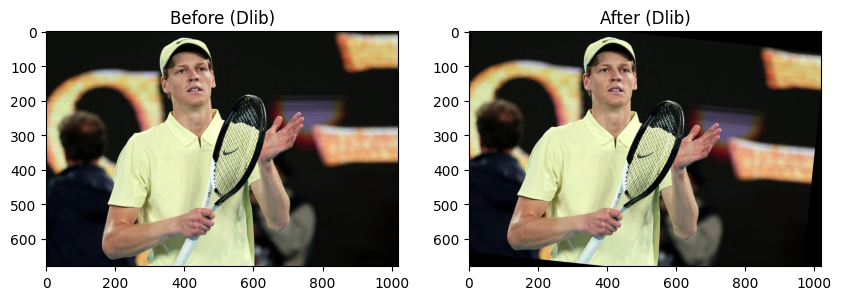

In [6]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

# Load models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def dlib_align_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)
    if len(faces) == 0:
        print("No face detected!")
        return image
    
    face = faces[0]
    landmarks = predictor(gray, face)

    left_eye = np.array([landmarks.part(36).x, landmarks.part(36).y])
    right_eye = np.array([landmarks.part(45).x, landmarks.part(45).y])

    dy, dx = right_eye[1] - left_eye[1], right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    center = ((left_eye[0] + right_eye[0]) / 2, (left_eye[1] + right_eye[1]) / 2)

    M = cv2.getRotationMatrix2D(center, angle, 1)
    aligned = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), flags=cv2.INTER_CUBIC)

    return aligned

# Load image
img_path = "../dataset/test/sinner/sinner.jpeg"
image = cv2.imread(img_path)
aligned = dlib_align_face(image)

# Show results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.title("Before (Dlib)")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)); plt.title("After (Dlib)")
plt.show()

## 3. Face Alignment using MTCNN ভিত্তিক (CNN-Driven Detection + Alignment)

E0000 00:00:1761534943.301180   12022 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761534943.308979   12022 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


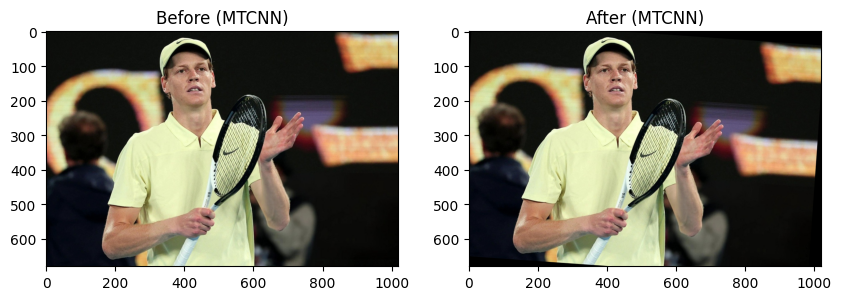

In [7]:
import cv2
import numpy as np
from mtcnn import MTCNN
import matplotlib.pyplot as plt

detector = MTCNN()

def mtcnn_align_face(image):
    results = detector.detect_faces(image)
    if len(results) == 0:
        print("No face detected!")
        return image

    result = results[0]
    keypoints = result['keypoints']
    left_eye = np.array(keypoints['left_eye'])
    right_eye = np.array(keypoints['right_eye'])

    dy, dx = right_eye[1] - left_eye[1], right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    center = ((left_eye[0] + right_eye[0]) / 2, (left_eye[1] + right_eye[1]) / 2)

    M = cv2.getRotationMatrix2D(center, angle, 1)
    aligned = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), flags=cv2.INTER_CUBIC)
    return aligned

# Load image
img_path = "../dataset/test/sinner/sinner.jpeg"
image = cv2.imread(img_path)
aligned = mtcnn_align_face(image)

# Show results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.title("Before (MTCNN)")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)); plt.title("After (MTCNN)")
plt.show()

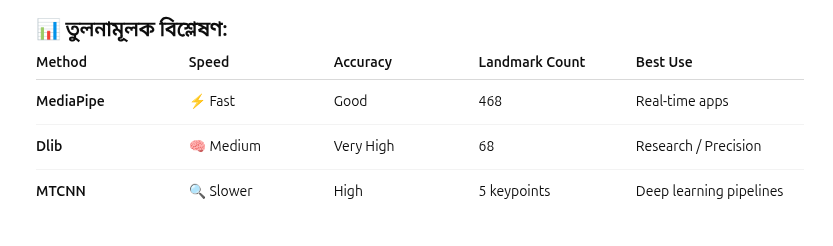

# 2. 5-point / 68-point Landmark detection

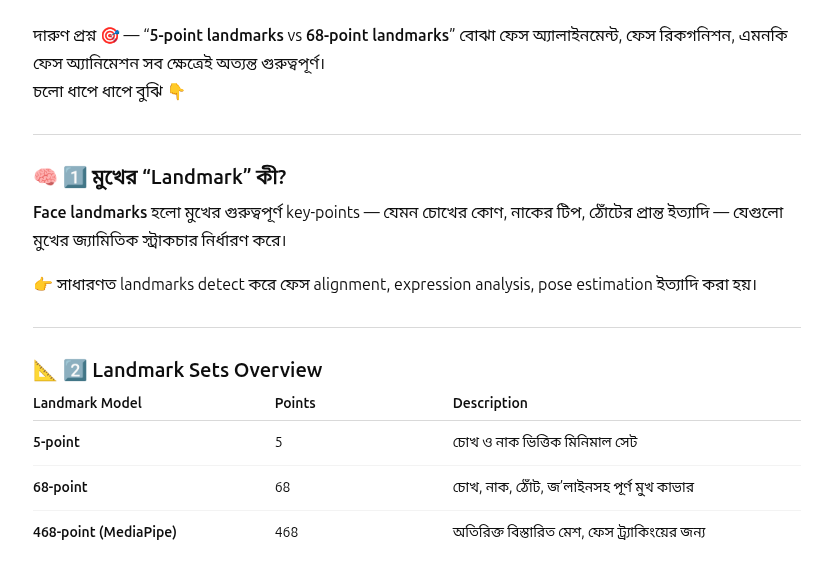

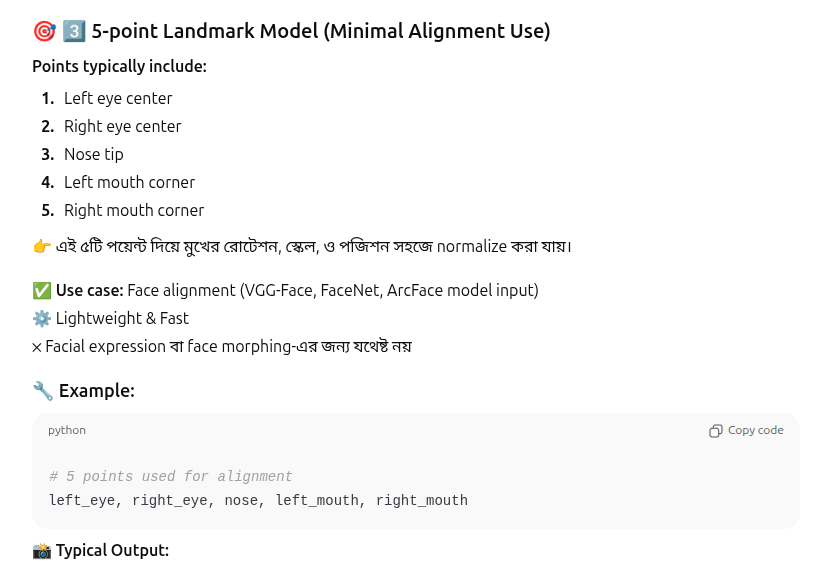

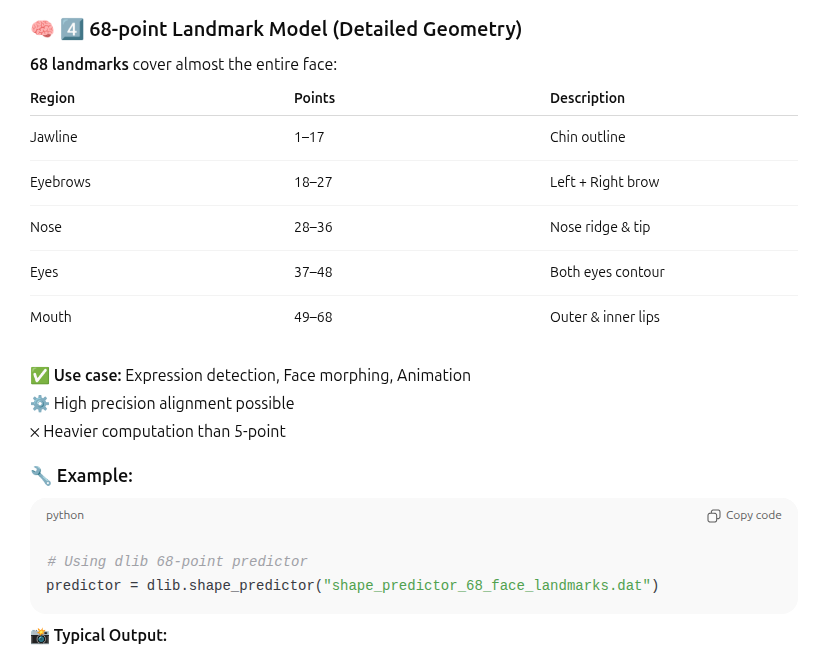

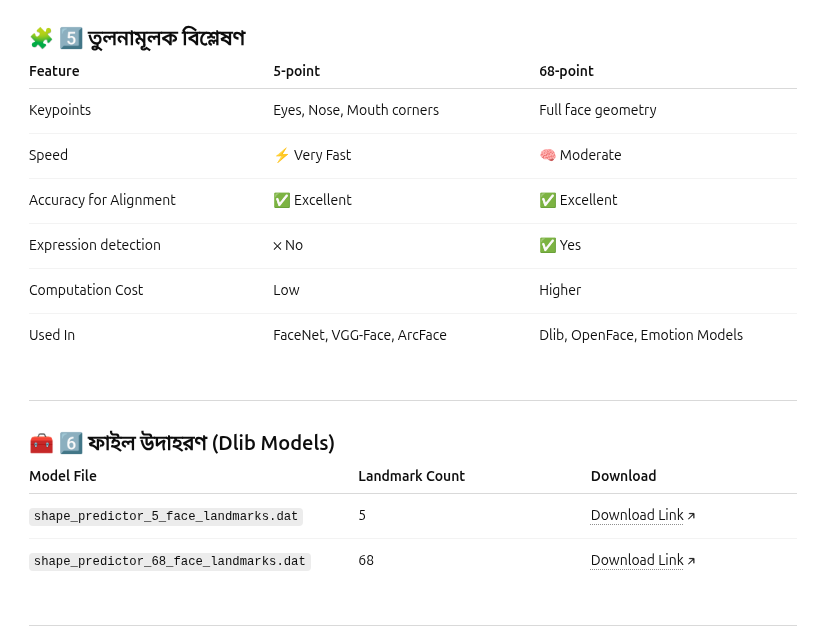

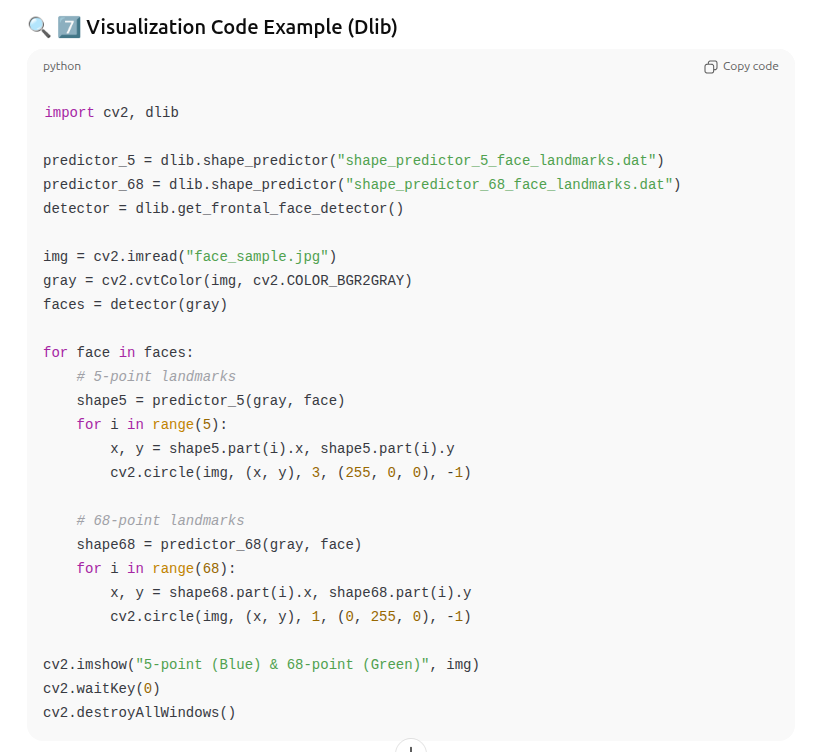

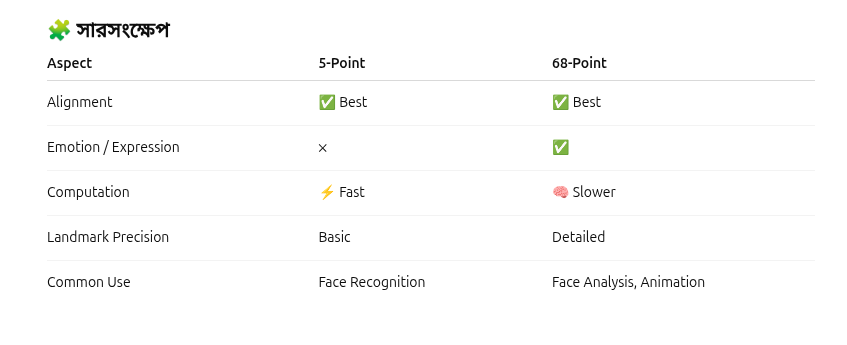

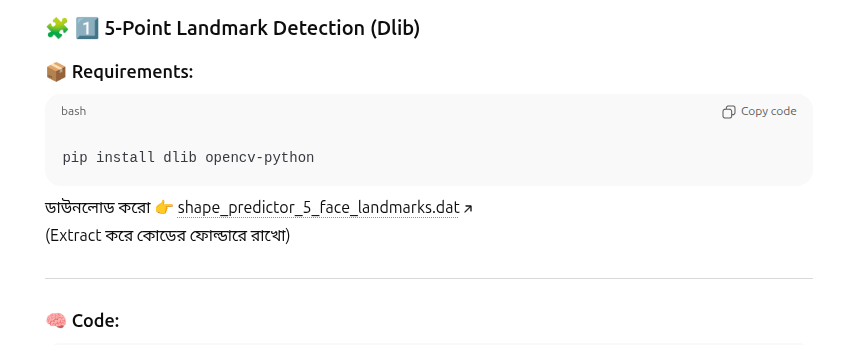

In [1]:
import cv2
import dlib

# Load Dlib models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_5_face_landmarks.dat")

# Load image
img_path = "../dataset/test/ronaldo/ronaldo.jpg"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = detector(gray)

for face in faces:
    landmarks = predictor(gray, face)
    for i in range(5):
        x, y = landmarks.part(i).x, landmarks.part(i).y
        cv2.circle(img, (x, y), 3, (0, 255, 0), -1)
        cv2.putText(img, str(i+1), (x+3, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

cv2.imshow("5-Point Landmarks", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

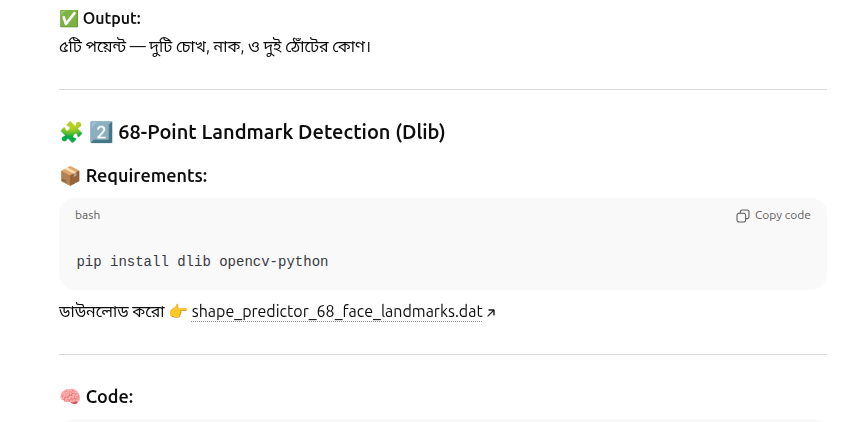

In [10]:
import cv2
import dlib

# Load models
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Load image
img_path = "../dataset/test/ronaldo/ronaldo.jpg"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = detector(gray)

for face in faces:
    landmarks = predictor(gray, face)
    for i in range(68):
        x, y = landmarks.part(i).x, landmarks.part(i).y
        cv2.circle(img, (x, y), 1, (0, 255, 0), -1)
        if i in [0,16,30,36,45,48,54]:  # Highlight key points
            cv2.putText(img, str(i+1), (x, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

cv2.imshow("68-Point Landmarks", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

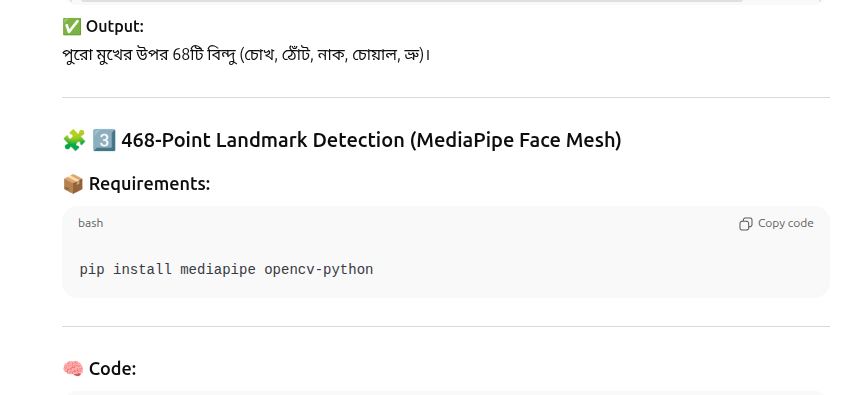

In [11]:
import cv2
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

# Initialize Face Mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

# Load image
img_path = "../dataset/test/ronaldo/ronaldo.jpg"
image = cv2.imread(img_path)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = face_mesh.process(rgb)

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = image.shape
        for i, lm in enumerate(face_landmarks.landmark):
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(image, (x, y), 1, (0, 255, 0), -1)
            if i in [1, 33, 61, 199, 263, 291]:  # Highlight few points
                cv2.putText(image, str(i), (x, y-2), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255,255,255), 1)

cv2.imshow("468-Point Landmarks (MediaPipe)", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

I0000 00:00:1761535851.107023   12022 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761535851.112221   14662 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1761535851.123446   14652 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761535851.160201   14655 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


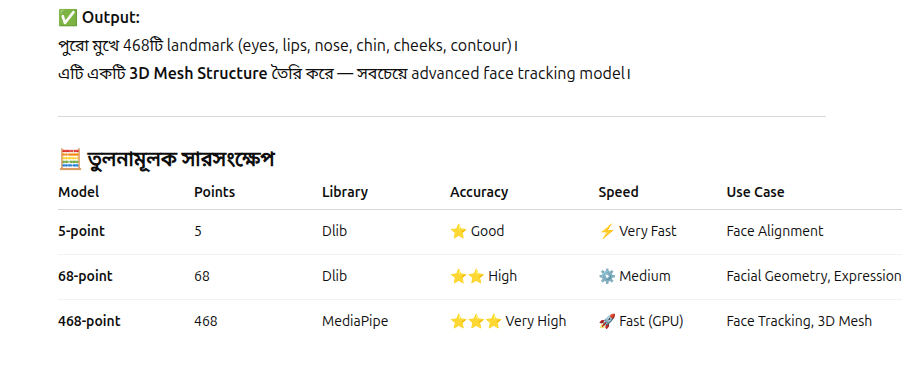

**4. MTCNN — Face Detection + Alignment Base (optional)**

In [2]:
# mtcnn_alignment_base.py
from mtcnn import MTCNN
import cv2

detector = MTCNN()
img = cv2.imread("../dataset/test/ronaldo/ronaldo.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = detector.detect_faces(rgb)
for r in results:
    keypoints = r['keypoints']
    for name, point in keypoints.items():
        cv2.circle(img, point, 3, (0, 255, 0), -1)
        cv2.putText(img, name, point, cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

cv2.imshow("MTCNN Keypoints", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

2025-10-27 09:39:54.693096: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 09:39:54.693785: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 09:39:54.796638: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
E0000 00:00:1761536400.754470   15209 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not b

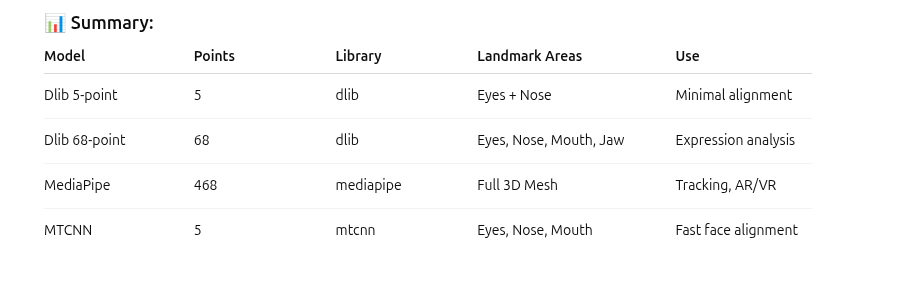

**3 Landmark Models Comparison**

I0000 00:00:1761536004.333978   12022 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761536004.337502   14892 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1761536004.345013   14886 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761536004.370746   14885 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


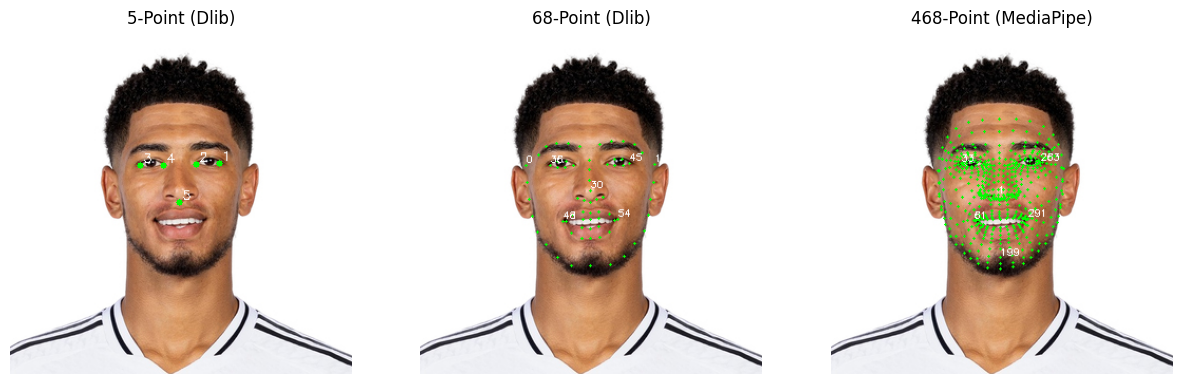

In [13]:
# ---------- Landmark Comparison: 5 / 68 / 468 ----------
import cv2
import dlib
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np

# --- Load Models ---
detector = dlib.get_frontal_face_detector()
predictor_5 = dlib.shape_predictor("shape_predictor_5_face_landmarks.dat")
predictor_68 = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
mp_face_mesh = mp.solutions.face_mesh

# --- Load Image ---
img_path = "../dataset/test/bellingham/bellingham.jpg"   # 🔁 এখানে নিজের ছবির path দাও
base_img = cv2.imread(img_path)

# --- Copy for each version ---
img_5 = base_img.copy()
img_68 = base_img.copy()
img_468 = base_img.copy()

gray = cv2.cvtColor(base_img, cv2.COLOR_BGR2GRAY)
faces = detector(gray)


# 1️⃣ Dlib 5-Point
if len(faces) > 0:
    face = faces[0]
    shape5 = predictor_5(gray, face)
    for i in range(5):
        x, y = shape5.part(i).x, shape5.part(i).y
        cv2.circle(img_5, (x, y), 3, (0, 255, 0), -1)
        cv2.putText(img_5, str(i+1), (x+3, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)


# 2️⃣ Dlib 68-Point
if len(faces) > 0:
    face = faces[0]
    shape68 = predictor_68(gray, face)
    for i in range(68):
        x, y = shape68.part(i).x, shape68.part(i).y
        cv2.circle(img_68, (x, y), 1, (0, 255, 0), -1)
    # Highlight key reference points
    for i in [0,16,30,36,45,48,54]:
        x, y = shape68.part(i).x, shape68.part(i).y
        cv2.putText(img_68, str(i), (x, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255,255,255), 1)


# 3️⃣ MediaPipe 468-Point
mp_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)
rgb = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
results = mp_mesh.process(rgb)

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = img_468.shape
        for i, lm in enumerate(face_landmarks.landmark):
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(img_468, (x, y), 1, (0, 255, 0), -1)
        # Highlight few important points
        for i in [1, 33, 61, 199, 263, 291]:
            lm = face_landmarks.landmark[i]
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.putText(img_468, str(i), (x, y-2), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255,255,255), 1)


# Show All Three Results
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_5, cv2.COLOR_BGR2RGB))
plt.title("5-Point (Dlib)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_68, cv2.COLOR_BGR2RGB))
plt.title("68-Point (Dlib)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_468, cv2.COLOR_BGR2RGB))
plt.title("468-Point (MediaPipe)")
plt.axis('off')

plt.show()

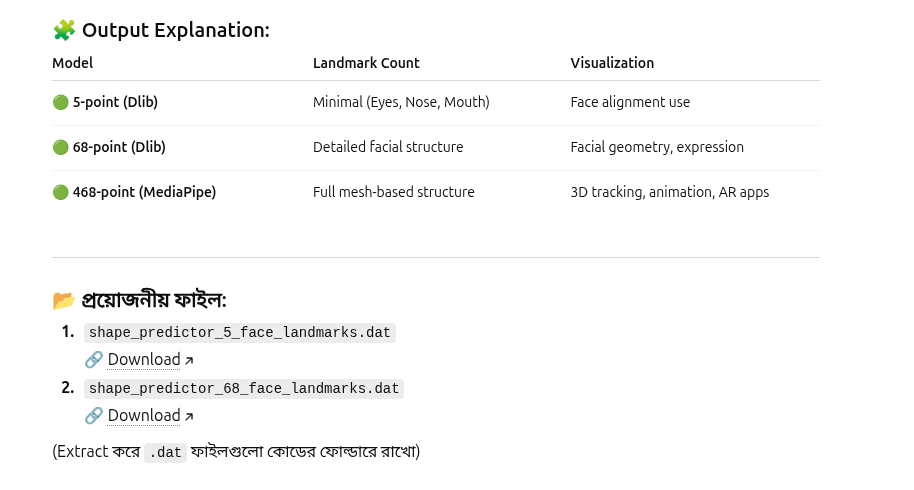

# 3. Landmark extraction (Dlib, Mediapipe)

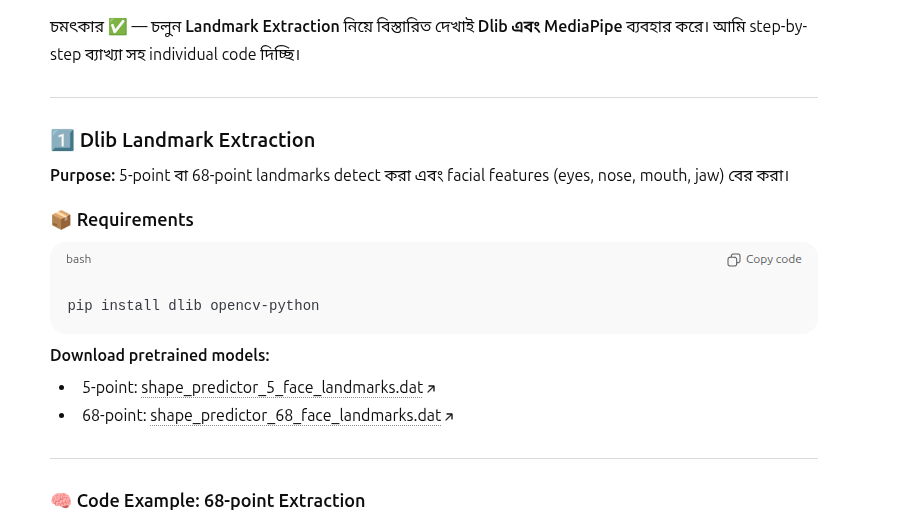

In [3]:
import cv2
import dlib

# Load detector and predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Load image
img = cv2.imread("../dataset/test/ronaldo/ronaldo.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = detector(gray)
for face in faces:
    landmarks = predictor(gray, face)
    coords = []
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        coords.append((x, y))
        cv2.circle(img, (x, y), 1, (0, 255, 0), -1)

cv2.imshow("68-point Landmarks", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# coords list contains all landmark (x, y) tuples
print(coords)

[(47, 186), (52, 215), (57, 243), (62, 270), (71, 294), (88, 314), (113, 328), (141, 336), (173, 338), (202, 334), (225, 323), (244, 306), (255, 285), (259, 260), (261, 234), (264, 209), (265, 184), (74, 160), (87, 143), (108, 138), (130, 141), (151, 150), (182, 152), (201, 145), (220, 141), (238, 146), (249, 161), (167, 169), (168, 185), (170, 201), (172, 219), (150, 234), (160, 235), (171, 237), (181, 235), (190, 233), (100, 176), (111, 167), (124, 167), (137, 176), (124, 179), (110, 179), (193, 177), (203, 168), (216, 169), (226, 177), (216, 180), (203, 180), (132, 274), (148, 264), (162, 258), (173, 260), (183, 257), (196, 261), (207, 270), (197, 276), (184, 281), (174, 282), (162, 282), (147, 279), (138, 273), (162, 267), (173, 267), (183, 266), (202, 269), (184, 267), (173, 269), (162, 268)]


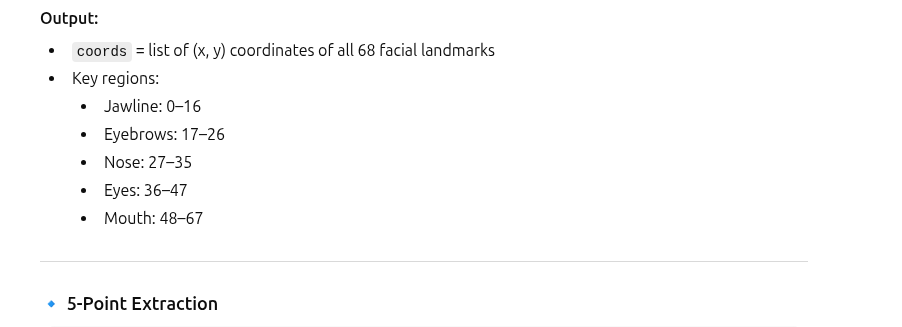

In [4]:
predictor_5 = dlib.shape_predictor("shape_predictor_5_face_landmarks.dat")
landmarks_5 = predictor_5(gray, faces[0])
coords_5 = [(landmarks_5.part(i).x, landmarks_5.part(i).y) for i in range(5)]
print(coords_5)

[(227, 176), (191, 175), (99, 174), (138, 175), (170, 239)]


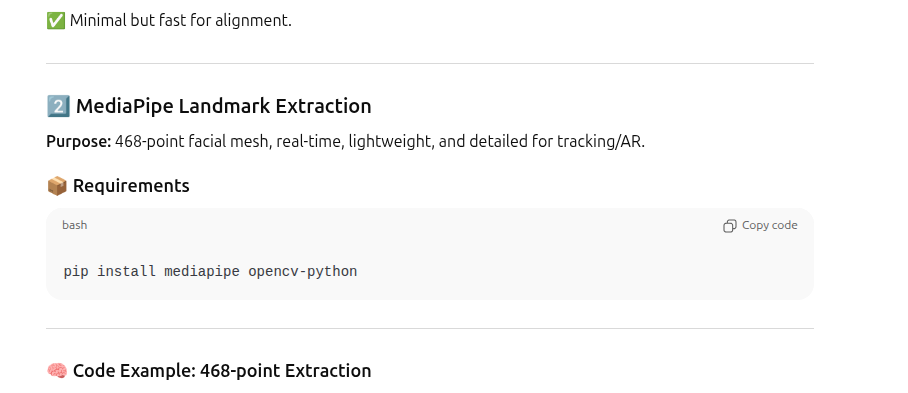

In [8]:
import cv2
import mediapipe as mp

# Initialize
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

mp_drawing = mp.solutions.drawing_utils
drawing_spec = mp_drawing.DrawingSpec(color=(0,255,0), thickness=1, circle_radius=1)

# Load image
img = cv2.imread("../dataset/test/ronaldo/ronaldo.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Process
results = face_mesh.process(rgb)
landmarks_list = []

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = img.shape
        for i, lm in enumerate(face_landmarks.landmark):
            x, y = int(lm.x * w), int(lm.y * h)
            landmarks_list.append((x, y))
        # Draw landmarks
        mp_drawing.draw_landmarks(img, face_landmarks, mp_face_mesh.FACEMESH_TESSELATION, drawing_spec, drawing_spec)

cv2.imshow("MediaPipe 468 Landmarks", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# landmarks_list contains all 468 (x, y) tuples
print(len(landmarks_list), landmarks_list[:])  # all 468 points

I0000 00:00:1761536791.558346   15209 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761536791.563764   16025 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1761536791.574072   16020 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761536791.604016   16016 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


478 [(174, 259), (173, 228), (171, 237), (163, 197), (173, 218), (172, 206), (169, 176), (104, 175), (168, 156), (168, 144), (166, 99), (174, 262), (173, 265), (173, 267), (173, 267), (173, 271), (173, 275), (173, 280), (171, 295), (173, 233), (163, 233), (60, 143), (128, 182), (119, 183), (111, 183), (99, 179), (136, 180), (115, 158), (126, 159), (106, 160), (100, 164), (90, 185), (135, 313), (100, 173), (57, 184), (78, 179), (123, 221), (162, 258), (163, 265), (151, 262), (142, 266), (154, 267), (146, 268), (128, 281), (165, 228), (164, 218), (86, 157), (141, 198), (141, 226), (140, 221), (94, 221), (164, 207), (110, 147), (96, 150), (71, 126), (151, 156), (135, 162), (120, 273), (64, 276), (148, 231), (156, 234), (133, 273), (135, 273), (90, 144), (140, 230), (128, 148), (126, 141), (112, 103), (80, 135), (119, 120), (79, 153), (69, 149), (163, 262), (152, 264), (144, 267), (150, 233), (134, 273), (139, 273), (137, 272), (153, 228), (148, 269), (155, 268), (164, 267), (159, 295), (1

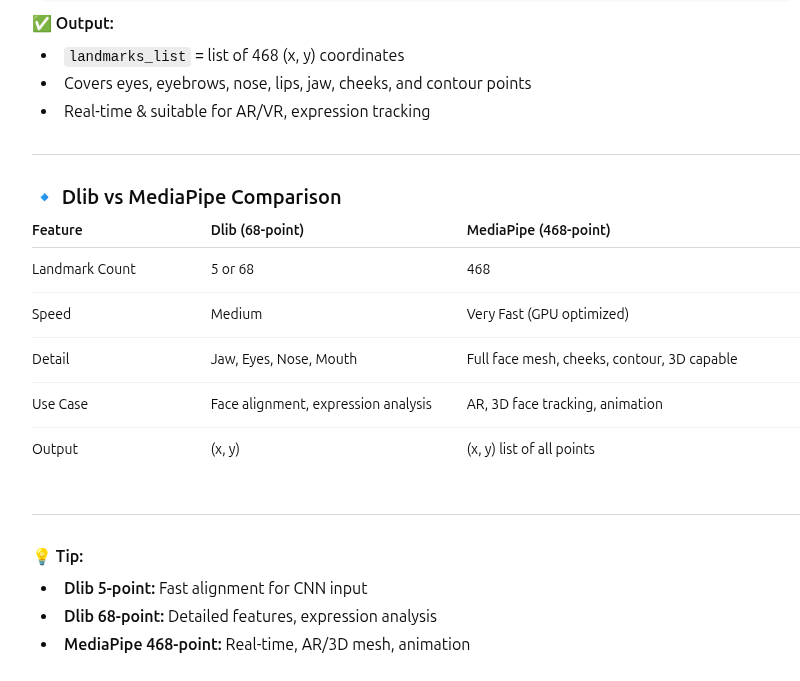